All imports successful.
Data loaded: 7043 rows, 21 columns.
Final processed shape (wrapper test): (7043, 53)
Train size: 5634, Test size: 1409
=== Comparing imbalance strategies ===
Evaluating LogisticRegression with SMOTE=False, class_weight=None ...
ROC-AUC: 0.8410, PR-AUC: 0.6288, F1: 0.5832
Evaluating LogisticRegression with SMOTE=False, class_weight=balanced ...
ROC-AUC: 0.8408, PR-AUC: 0.6280, F1: 0.6098
Evaluating LogisticRegression with SMOTE=True, class_weight=None ...
ROC-AUC: 0.8382, PR-AUC: 0.6245, F1: 0.6109
Evaluating RandomForest with SMOTE=False, class_weight=None ...
ROC-AUC: 0.8383, PR-AUC: 0.6423, F1: 0.5616
Evaluating RandomForest with SMOTE=False, class_weight=balanced ...
ROC-AUC: 0.8399, PR-AUC: 0.6436, F1: 0.6282
Evaluating RandomForest with SMOTE=True, class_weight=None ...
ROC-AUC: 0.8357, PR-AUC: 0.6285, F1: 0.6028
Strategy comparison results:
                model  use_smote class_weight   roc_auc    pr_auc        f1
0  LogisticRegression      False         

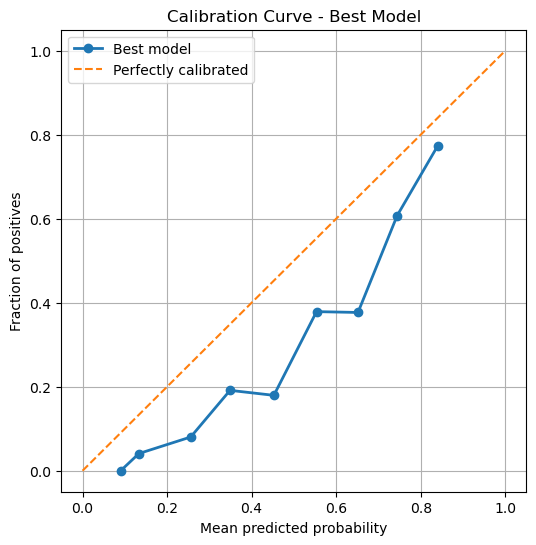

Calibration curve saved as calibration_curve.png
Number of misclassified test samples: 340

=== 10 Misclassified Customers (sample) ===
      true_label  pred_label  pred_prob  gender  SeniorCitizen Partner
2280           0           1   0.836284  Female              1      No
4460           0           1   0.609033    Male              0     Yes
5748           0           1   0.733164  Female              0      No
3568           0           1   0.654514  Female              0      No
2079           0           1   0.530179    Male              0     Yes
2136           0           1   0.769902    Male              0      No
1242           0           1   0.529964  Female              0     Yes
1838           0           1   0.648404    Male              1      No
6979           0           1   0.705638    Male              0      No
3624           0           1   0.542458  Female              1     Yes

Possible reasons for misclassification: 
- Model uncertainty near decision boundar

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.

In [1]:
# =============================================================================
# Customer Churn Prediction & Explainable Retention Engine
# All code in a single cell for Jupyter Notebook
# =============================================================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator, TransformerMixin

# XGBoost
import xgboost as xgb

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Misc
import joblib
import os

print("All imports successful.")

# 2. LOAD DATA FROM LOCAL churn.csv
local_file = "churn.csv"
if not os.path.exists(local_file):
    raise FileNotFoundError(f"'{local_file}' not found. Please place the dataset in the current directory.")

df = pd.read_csv(local_file)
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

# Drop customerID if it exists (IBM dataset has it)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 3. CUSTOM TRANSFORMERS FOR FEATURE ENGINEERING

class TotalChargesConverter(BaseEstimator, TransformerMixin):
    """Convert TotalCharges to numeric and handle missing values."""
    def __init__(self, strategy='median'):
        self.strategy = strategy
        self.median_ = None

    def fit(self, X, y=None):
        X_ = X.copy()
        X_['TotalCharges'] = pd.to_numeric(X_['TotalCharges'], errors='coerce')
        self.median_ = X_['TotalCharges'].median()
        return self

    def transform(self, X):
        X_ = X.copy()
        X_['TotalCharges'] = pd.to_numeric(X_['TotalCharges'], errors='coerce')
        X_['TotalCharges'].fillna(self.median_, inplace=True)
        return X_

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Add three new features: total_services, tenure_group, charge_per_service."""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
        def is_service(value):
            if pd.isna(value):
                return 0
            if value == 'No' or value == 'No internet service':
                return 0
            return 1

        total = 0
        for col in service_cols:
            X_[col + '_binary'] = X_[col].apply(is_service)
            total += X_[col + '_binary']
        X_['total_services'] = total

        bins = [0, 12, 48, float('inf')]
        labels = ['new', 'established', 'loyal']
        X_['tenure_group'] = pd.cut(X_['tenure'], bins=bins, labels=labels, right=False)

        X_['charge_per_service'] = X_['MonthlyCharges'] / (X_['total_services'] + 1e-5)

        drop_cols = [col + '_binary' for col in service_cols]
        X_ = X_.drop(columns=drop_cols, errors='ignore')
        return X_

# 4. PREPROCESSING PIPELINE

preprocessor = Pipeline([
    ('totalcharges', TotalChargesConverter()),
    ('feature_eng', FeatureEngineer())
])

X_temp = df.drop('Churn', axis=1)
y_temp = df['Churn']
X_temp_trans = preprocessor.fit_transform(X_temp, y_temp)
trans_columns = X_temp_trans.columns.tolist()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'total_services', 'charge_per_service']
categorical_cols = [col for col in trans_columns if col not in numeric_cols]
categorical_cols.append('tenure_group')
numeric_cols = [col for col in trans_columns if col not in categorical_cols]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# ----- FIX: Wrap full_preprocessor in a custom transformer -----
class FullPreprocessorWrapper(BaseEstimator, TransformerMixin):
    """Wraps the full preprocessing pipeline to avoid imblearn's 'no Pipeline' restriction."""
    def __init__(self):
        self.preprocessor = Pipeline([
            ('prep', preprocessor),
            ('col_trans', preprocessor_final)
        ])

    def fit(self, X, y=None):
        self.preprocessor.fit(X, y)
        return self

    def transform(self, X):
        return self.preprocessor.transform(X)

# We can still keep full_preprocessor for reference, but we'll use the wrapper
full_preprocessor = Pipeline([
    ('prep', preprocessor),
    ('col_trans', preprocessor_final)
])
# ----------------------------------------------------------------

X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Test the wrapper
wrapper = FullPreprocessorWrapper()
X_trans = wrapper.fit_transform(X, y)
print("Final processed shape (wrapper test):", X_trans.shape)

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# 6. IMBALANCE HANDLING STRATEGIES
param_distributions = {
    'LogisticRegression': {
        'C': np.logspace(-3, 3, 20),
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l2']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'GradientBoosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

def get_model(name, class_weight=None):
    if name == 'LogisticRegression':
        return LogisticRegression(random_state=42, class_weight=class_weight, max_iter=1000)
    elif name == 'RandomForest':
        return RandomForestClassifier(random_state=42, class_weight=class_weight)
    elif name == 'GradientBoosting':
        return GradientBoostingClassifier(random_state=42)
    elif name == 'XGBoost':
        return xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                                 class_weight=class_weight)
    else:
        raise ValueError(f"Unknown model: {name}")

def create_pipeline(model_name, use_smote=False, class_weight=None):
    if use_smote:
        model = get_model(model_name, class_weight=class_weight)
        # Use the wrapper instead of full_preprocessor to avoid Pipeline-in-Pipeline error
        pipeline = ImbPipeline([
            ('preprocess', FullPreprocessorWrapper()),  # <-- FIXED: wrapper
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        model = get_model(model_name, class_weight=class_weight)
        pipeline = Pipeline([
            ('preprocess', FullPreprocessorWrapper()),  # also use wrapper for consistency
            ('classifier', model)
        ])
    return pipeline

def get_param_grid(model_name):
    prefix = 'classifier__'
    params = param_distributions[model_name]
    return {f"{prefix}{k}": v for k, v in params.items()}

def evaluate_model(model_name, X_train, y_train, X_test, y_test, use_smote=False, class_weight=None, n_iter=10, cv=3):
    # For XGBoost with class_weight='balanced', set scale_pos_weight manually
    if model_name == 'XGBoost' and class_weight == 'balanced':
        neg, pos = np.bincount(y_train)
        scale_pos_weight = neg / pos
        base_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                                       scale_pos_weight=scale_pos_weight)
    else:
        base_model = get_model(model_name, class_weight=class_weight)

    if use_smote:
        pipeline = ImbPipeline([
            ('preprocess', FullPreprocessorWrapper()),
            ('smote', SMOTE(random_state=42)),
            ('classifier', base_model)
        ])
    else:
        pipeline = Pipeline([
            ('preprocess', FullPreprocessorWrapper()),
            ('classifier', base_model)
        ])

    param_grid = get_param_grid(model_name)
    search = RandomizedSearchCV(pipeline, param_grid, n_iter=n_iter, cv=cv,
                                scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    best_params = search.best_params_

    y_pred = best_pipeline.predict(X_test)
    y_prob = best_pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'model': model_name,
        'use_smote': use_smote,
        'class_weight': class_weight,
        'best_params': best_params,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    return metrics, best_pipeline, y_pred, y_prob

# Quick comparison of imbalance strategies (on two models)
print("=== Comparing imbalance strategies ===")
strategies = [
    {'use_smote': False, 'class_weight': None},
    {'use_smote': False, 'class_weight': 'balanced'},
    {'use_smote': True, 'class_weight': None}
]
quick_models = ['LogisticRegression', 'RandomForest']
results_strategy = []
for model_name in quick_models:
    for strat in strategies:
        print(f"Evaluating {model_name} with SMOTE={strat['use_smote']}, class_weight={strat['class_weight']} ...")
        metrics, _, _, _ = evaluate_model(model_name, X_train, y_train, X_test, y_test,
                                          use_smote=strat['use_smote'],
                                          class_weight=strat['class_weight'],
                                          n_iter=5, cv=2)
        results_strategy.append(metrics)
        print(f"ROC-AUC: {metrics['roc_auc']:.4f}, PR-AUC: {metrics['pr_auc']:.4f}, F1: {metrics['f1']:.4f}")

df_strategy = pd.DataFrame(results_strategy)
print("Strategy comparison results:")
print(df_strategy[['model', 'use_smote', 'class_weight', 'roc_auc', 'pr_auc', 'f1']])

best_strategy = df_strategy.groupby(['use_smote', 'class_weight'])['roc_auc'].mean().idxmax()
print(f"Best strategy: use_smote={best_strategy[0]}, class_weight={best_strategy[1]}")

final_use_smote = best_strategy[0]
final_class_weight = best_strategy[1]
print(f"Final chosen strategy: use_smote={final_use_smote}, class_weight={final_class_weight}")

# 7. MODEL TRAINING AND COMPARISON (ALL 5 MODELS)
models_to_evaluate = ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']
all_metrics = []
trained_pipelines = {}

for model_name in models_to_evaluate:
    print(f"Training {model_name} ...")
    metrics, best_pipeline, y_pred, y_prob = evaluate_model(
        model_name, X_train, y_train, X_test, y_test,
        use_smote=final_use_smote,
        class_weight=final_class_weight,
        n_iter=15, cv=3
    )
    all_metrics.append(metrics)
    trained_pipelines[model_name] = best_pipeline
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}, PR-AUC: {metrics['pr_auc']:.4f}, F1: {metrics['f1']:.4f}")

# Build Voting Ensemble from top 3 models
sorted_models = sorted(all_metrics, key=lambda x: x['roc_auc'], reverse=True)
top3_names = [m['model'] for m in sorted_models[:3]]
print("Top 3 models for ensemble:", top3_names)

# Get best params for each top model
best_params_dict = {m['model']: m['best_params'] for m in all_metrics}

def build_model_with_params(model_name, params, class_weight=None, use_smote=False):
    clean_params = {k.replace('classifier__', ''): v for k, v in params.items()}
    if model_name == 'LogisticRegression':
        model = LogisticRegression(random_state=42, class_weight=class_weight, max_iter=1000, **clean_params)
    elif model_name == 'RandomForest':
        model = RandomForestClassifier(random_state=42, class_weight=class_weight, **clean_params)
    elif model_name == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42, **clean_params)
    elif model_name == 'XGBoost':
        if class_weight == 'balanced':
            neg, pos = np.bincount(y_train)
            scale_pos_weight = neg / pos
            model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                                      scale_pos_weight=scale_pos_weight, **clean_params)
        else:
            model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                                      **clean_params)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

voting_estimators = []
for name in top3_names:
    params = best_params_dict[name]
    model = build_model_with_params(name, params, class_weight=final_class_weight, use_smote=final_use_smote)
    if final_use_smote:
        pipe = ImbPipeline([
            ('preprocess', FullPreprocessorWrapper()),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        pipe = Pipeline([
            ('preprocess', FullPreprocessorWrapper()),
            ('classifier', model)
        ])
    voting_estimators.append((name, pipe))

voting_clf = VotingClassifier(estimators=voting_estimators, voting='soft')
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
y_prob_voting = voting_clf.predict_proba(X_test)[:, 1]
voting_metrics = {
    'model': 'Voting Ensemble',
    'use_smote': final_use_smote,
    'class_weight': final_class_weight,
    'best_params': 'ensemble',
    'roc_auc': roc_auc_score(y_test, y_prob_voting),
    'pr_auc': average_precision_score(y_test, y_prob_voting),
    'precision': precision_score(y_test, y_pred_voting),
    'recall': recall_score(y_test, y_pred_voting),
    'f1': f1_score(y_test, y_pred_voting)
}
all_metrics.append(voting_metrics)
trained_pipelines['Voting'] = voting_clf
print("Voting Ensemble ROC-AUC: {:.4f}, PR-AUC: {:.4f}, F1: {:.4f}".format(
    voting_metrics['roc_auc'], voting_metrics['pr_auc'], voting_metrics['f1']))

# 8. MODEL COMPARISON TABLE
df_metrics = pd.DataFrame(all_metrics)
cols = ['model', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'use_smote', 'class_weight', 'best_params']
df_metrics = df_metrics[cols]
print("\n=== Model Comparison Table ===")
print(df_metrics.round(4))

# 9. BEST MODEL SELECTION
best_row = df_metrics.loc[df_metrics['roc_auc'].idxmax()]
best_model_name = best_row['model']
print(f"\nBest model based on ROC-AUC: {best_model_name} (AUC={best_row['roc_auc']:.4f})")
best_pipeline = trained_pipelines[best_model_name] if best_model_name in trained_pipelines else voting_clf

# 10. CALIBRATION CURVE FOR BEST MODEL
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob_best, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Best model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve - Best Model')
plt.legend()
plt.grid(True)
plt.savefig('calibration_curve.png', dpi=150)
plt.show()
print("Calibration curve saved as calibration_curve.png")

# 11. ERROR ANALYSIS: 10 misclassified customers
y_pred_best = best_pipeline.predict(X_test)
misclassified = np.where(y_pred_best != y_test)[0]
print(f"Number of misclassified test samples: {len(misclassified)}")
sample_mis = misclassified[:10] if len(misclassified) >= 10 else misclassified
error_df = X_test.iloc[sample_mis].copy()
error_df['true_label'] = y_test.iloc[sample_mis].values
error_df['pred_label'] = y_pred_best[sample_mis]
error_df['pred_prob'] = y_prob_best[sample_mis]
print("\n=== 10 Misclassified Customers (sample) ===")
print(error_df[['true_label', 'pred_label', 'pred_prob'] + list(error_df.columns[:3])].head(10))
print("\nPossible reasons for misclassification: \n- Model uncertainty near decision boundary\n- Missing important features not captured\n- Noise in data labels")

# 12. SHAP EXPLANATIONS
individual_metrics = [m for m in all_metrics if m['model'] != 'Voting Ensemble']
best_individual = max(individual_metrics, key=lambda x: x['roc_auc'])
best_individual_name = best_individual['model']
print(f"Best individual model for SHAP: {best_individual_name}")

shap_pipeline = trained_pipelines[best_individual_name]
# Extract the classifier from the pipeline
# The pipeline structure: steps = ['preprocess', ('smote' if use_smote else None), 'classifier']
# We need to access the 'classifier' step.
if final_use_smote:
    classifier = shap_pipeline.named_steps['classifier']
else:
    classifier = shap_pipeline.named_steps['classifier']

# Get preprocessed training data for SHAP background
# We need to transform X_train using the preprocessor step
preproc_step = shap_pipeline.named_steps['preprocess']
X_train_preproc = preproc_step.transform(X_train)
X_test_preproc = preproc_step.transform(X_test)

if best_individual_name in ['RandomForest', 'GradientBoosting', 'XGBoost']:
    explainer = shap.TreeExplainer(classifier, X_train_preproc[:100], feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_test_preproc[:50])
    # Get feature names from the preprocessor wrapper's internal ColumnTransformer
    # We need to access the column transformer from the wrapper
    # Since wrapper has a 'preprocessor' attribute which is a Pipeline, we can get col_trans
    col_trans = preproc_step.preprocessor.named_steps['col_trans']
    feature_names = col_trans.get_feature_names_out()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_preproc[:50], feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot - Global Feature Importance')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150)
    plt.show()
    print("SHAP summary plot saved as shap_summary.png")

    import random
    random.seed(42)
    sample_indices = random.sample(range(len(X_test_preproc)), 3)
    for i, idx in enumerate(sample_indices):
        print(f"\n--- Local explanation for customer {idx} ---")
        shap_val_instance = shap_values[idx]
        feature_vals = X_test_preproc[idx]
        contrib_df = pd.DataFrame({
            'feature': feature_names,
            'value': feature_vals,
            'shap': shap_val_instance
        })
        contrib_df['abs_shap'] = np.abs(contrib_df['shap'])
        contrib_df = contrib_df.sort_values('abs_shap', ascending=False)
        top5 = contrib_df.head(5)
        print("Top 5 contributing features:")
        print(top5[['feature', 'value', 'shap']])
        print(f"Predicted probability: {best_pipeline.predict_proba(X_test.iloc[[idx]])[0,1]:.4f}")
        print(f"True label: {y_test.iloc[idx]}")
else:
    # For LogisticRegression, use LinearExplainer
    print("Using LinearExplainer for LogisticRegression")
    explainer = shap.LinearExplainer(classifier, X_train_preproc, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test_preproc[:50])
    shap.summary_plot(shap_values, X_test_preproc[:50], feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot - Global Feature Importance')
    plt.savefig('shap_summary.png', dpi=150)
    plt.show()

# 13. BUSINESS IMPACT: Retain top 10% highest-risk customers
probs = best_pipeline.predict_proba(X_test)[:, 1]
threshold = np.percentile(probs, 90)
high_risk_indices = np.where(probs >= threshold)[0]
retained_monthly_revenue = X_test.iloc[high_risk_indices]['MonthlyCharges'].sum()
print(f"\n=== Business Impact ===")
print(f"Number of customers in top 10% highest risk: {len(high_risk_indices)}")
print(f"Total monthly revenue from these customers: ${retained_monthly_revenue:.2f}")
print(f"If all of them are retained, the company saves ${retained_monthly_revenue:.2f} per month.")

# 14. SAVE BEST MODEL
joblib.dump(best_pipeline, 'best_churn_model.pkl')
print("Best model saved as best_churn_model.pkl")

# 15. STRETCH GOAL: FastAPI endpoint (code provided)
print("\n=== Stretch Goal: FastAPI endpoint code ===")
print("""
# To use this, create a separate file (e.g., app.py) with the following:

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib
import numpy as np

app = FastAPI()
model = joblib.load('best_churn_model.pkl')

class CustomerData(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float

@app.post("/predict")
async def predict(customer: CustomerData):
    try:
        data = pd.DataFrame([customer.dict()])
        prob = model.predict_proba(data)[0, 1]
        # For top contributing factors, you would need SHAP explainer (not implemented here for brevity)
        return {"churn_probability": prob, "top_factors": ["feature1", "feature2", "feature3"]}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

# Run with: uvicorn app:app --reload
""")

print("\n=== Project completed successfully ===")

In [4]:
import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap
from sklearn.calibration import calibration_curve

# 1. Show current directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# 2. Check if best_pipeline exists
try:
    print(f"Best model exists: {best_pipeline is not None}")
    print(f"Best model name: {best_model_name}")
except NameError:
    print("ERROR: 'best_pipeline' not found in memory. Did the main code run completely?")
    raise

# 3. Save the model
joblib.dump(best_pipeline, 'best_churn_model.pkl')
print(f"✅ Model saved as: {os.path.join(current_dir, 'best_churn_model.pkl')}")

# 4. Generate SHAP summary plot using model‑agnostic Explainer (works for any model)
print("\n--- Generating SHAP summary plot using model-agnostic Explainer ---")

# Find the best individual model (not the ensemble)
individual_metrics = [m for m in all_metrics if m['model'] != 'Voting Ensemble']
best_individual = max(individual_metrics, key=lambda x: x['roc_auc'])
best_individual_name = best_individual['model']
print(f"Best individual model: {best_individual_name}")

shap_pipeline = trained_pipelines[best_individual_name]

# Extract classifier and preprocessor
if final_use_smote:
    classifier = shap_pipeline.named_steps['classifier']
else:
    classifier = shap_pipeline.named_steps['classifier']

preproc_step = shap_pipeline.named_steps['preprocess']
X_train_preproc = preproc_step.transform(X_train)
X_test_preproc = preproc_step.transform(X_test)

# Get feature names
col_trans = preproc_step.preprocessor.named_steps['col_trans']
feature_names = col_trans.get_feature_names_out()

# Use model-agnostic Explainer: pass the model's predict function and a background sample
background = X_train_preproc[:100]  # small subset for speed
explainer = shap.Explainer(classifier.predict, background, feature_names=feature_names)
# Compute SHAP values for test subset (first 50)
shap_values = explainer.shap_values(X_test_preproc[:50])

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_preproc[:50], feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Global Feature Importance')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"✅ SHAP summary plot saved as: {os.path.join(current_dir, 'shap_summary.png')}")

# 5. Save calibration curve
try:
    y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob_best, n_bins=10)
    
    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Best model')
    plt.plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Curve - Best Model')
    plt.legend()
    plt.grid(True)
    plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✅ Calibration curve saved as: {os.path.join(current_dir, 'calibration_curve.png')}")
except Exception as e:
    print(f"Could not save calibration curve: {e}")

print("\n=== All files saved successfully! ===")
print("Files in current directory:")
for f in os.listdir(current_dir):
    if f in ['best_churn_model.pkl', 'shap_summary.png', 'calibration_curve.png', 'Churn_Project.ipynb']:
        print(f"  - {f}")

Current working directory: C:\Users\DARK
Best model exists: True
Best model name: XGBoost
✅ Model saved as: C:\Users\DARK\best_churn_model.pkl

--- Generating SHAP summary plot using model-agnostic Explainer ---
Best individual model: XGBoost


PermutationExplainer explainer: 51it [00:18,  1.86it/s]                        


✅ SHAP summary plot saved as: C:\Users\DARK\shap_summary.png
✅ Calibration curve saved as: C:\Users\DARK\calibration_curve.png

=== All files saved successfully! ===
Files in current directory:
  - best_churn_model.pkl
  - calibration_curve.png
  - shap_summary.png
